# Rede neural com camadas escondidas - Classificação do Iris dataset

O objetivo desse experimento é ilustrar o uso de rede neural que tenha mais de uma camada. Isso é conseguido com a inserção de uma ativação não linear entre as camadas.

Datasets utilizados:
    - Iris - 3 classes
    - Sintéticos:
        - meia luas
        - círculos circunscritos
        - blobs

![alt text](https://raw.githubusercontent.com/vcasadei/images/master/Net2RegressaoSoftmaxArgmaxRede.png)

## Importando as bibliotecas

In [15]:
%matplotlib inline
from sklearn import datasets
from IPython import display
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
from torch.autograd import Variable
import torch.nn as nn

## Leitura, normalização e visualização dos dados

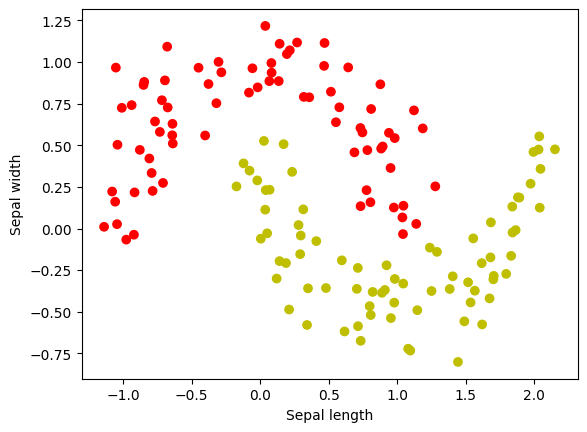

In [16]:
n_samples = 150
options = ['iris', 'moon', 'circles', 'blobs']
option = options[1]
if option == 'iris':
    iris = datasets.load_iris()
    X = iris.data[:,:2]  # comprimento das sépalas e pétalas, indices 0 e 2
    Xc = X - X.min(axis=0)
    Xc /= Xc.max(axis=0)
    Y = iris.target
elif option == 'moon':
    Xc,Y = datasets.make_moons(n_samples=n_samples, noise=.15)
elif option == 'circles':
    Xc,Y = datasets.make_circles(n_samples=n_samples, factor=.5, noise=.1)
elif option == 'blobs':
    Xc,Y = datasets.make_blobs(n_samples=n_samples,centers=3,cluster_std=1.2)

colors = np.array(['r','y','b'])
plt.scatter(Xc[:, 0], Xc[:, 1], c=colors[Y])
plt.xlabel('Sepal length')
plt.ylabel('Sepal width')
plt.show()

### Prepara os dados para o PyTorch

In [17]:
X_tensor = torch.FloatTensor(Xc)
Y_tensor = torch.LongTensor(Y)

## Construindo o modelo da rede

In [18]:
class Modelo(nn.Module):
    def __init__(self):
        super(Modelo, self).__init__()
        self.dense = nn.Sequential(
            nn.Linear(2, 5),
            nn.ReLU(),
            nn.Linear(5, 5),
            nn.ReLU(),
            nn.Linear(5,3),
        )

    def forward(self, x):
        x = self.dense(x)

        return x

model = Modelo()
print(model)

Modelo(
  (dense): Sequential(
    (0): Linear(in_features=2, out_features=5, bias=True)
    (1): ReLU()
    (2): Linear(in_features=5, out_features=5, bias=True)
    (3): ReLU()
    (4): Linear(in_features=5, out_features=3, bias=True)
  )
)


## _predict_ utilizada para predição de classes e na visualização

In [19]:
def predict(model, inputs):
    outputs = model(Variable(inputs))
    _, predicts = torch.max(outputs, 1)

    return predicts.data.numpy()

## Classe para visualização dinâmica

In [20]:
class BoundaryPlotter():
    def __init__(self, model, X, Y, n_epoch, filepath=None, h = .01):
        self.model = model
        self.X = X
        self.Y = Y
        self.n_epoch = n_epoch
        self.filepath = filepath
        x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
        y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
        self.xx, self.yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
        self.loss_hist = []
        self.val_loss_hist = []
        self.X_grid = np.c_[self.xx.ravel(), self.yy.ravel()]

        #Gráficos a serem mostrados pelo callback
        self.fig = plt.figure(figsize=(8, 4), dpi=100)
        self.ax1 = self.fig.add_subplot(1, 2, 1)
        self.ax1.set_xlim(0, nb_epoch)
        self.ax1.set_xlabel('Epoca')#,fontsize=28)
        self.ax1.set_ylabel('Perda')#,fontsize=28)
        self.ax1.plot([],[],'b',linewidth = 2.0,label = "Treino")
        self.ax1.grid(True)

        self.ax2 = self.fig.add_subplot(1, 2, 2)
        self.ax2.set_xlim(Xc[:,0].min(), Xc[:,0].max())
        self.ax2.set_ylim(Xc[:,1].min(), Xc[:,1].max())
        self.ax2.set_xlabel('Comprimento da Sepala')#,fontsize=28)
        self.ax2.set_ylabel('Largura da Sepala')#,fontsize=28)

    def on_train_begin(self, logs={}):
        display.display(self.fig)
        display.clear_output(wait=True)

    def on_epoch_end(self, epoch, logs={}):
        if 'loss' in logs.keys():
            self.loss_hist.append(logs['loss'])

            if epoch%250==0:
                self.ax1.plot(np.arange(epoch+1), self.loss_hist, 'b', linewidth = 2.0)

                Z = predict(self.model, torch.from_numpy(self.X_grid).type(torch.FloatTensor))
#                 Z = torch.max(self.model(Variable(torch.FloatTensor(self.X_grid))).data, dim=1)[1].numpy()
                Z = Z.reshape(self.xx.shape)

                self.ax2.pcolormesh(self.xx, self.yy, Z, cmap=plt.cm.Paired)
                colors = np.array(['r','y','b'])
                self.ax2.scatter(self.X[:, 0], self.X[:, 1], s=40, c=colors[self.Y], edgecolors='k', cmap=plt.cm.Paired)

                display.display(self.fig)
                display.clear_output(wait=True)

## Treinamento

In [21]:
lr = 0.15

optimizer = torch.optim.SGD(model.parameters(), lr=lr)

criterion = nn.CrossEntropyLoss()

### Laço principal de treinamento

Final loss: tensor(0.2150)


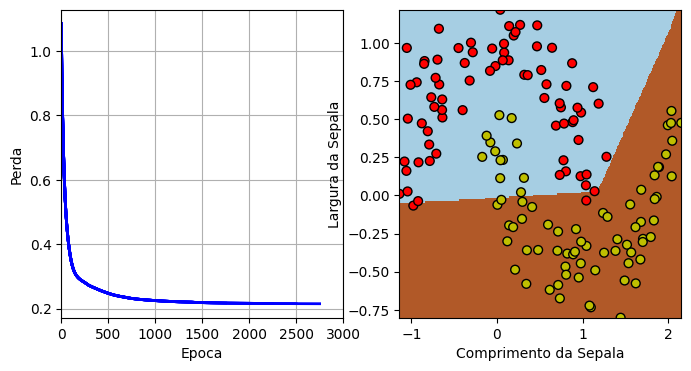

In [22]:
batch_size = 150
nb_epoch = 3000

#Definindo o plotter
boundary_plot = BoundaryPlotter(model, Xc, Y, nb_epoch)

boundary_plot.on_train_begin()
losses = []
for i in range(nb_epoch):
    # predict da rede
    output = model(Variable(X_tensor))

    loss = criterion(output, Variable(Y_tensor))

    # zero, backpropagation gradient, atualiza param gradiente descendente
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.data)

    boundary_plot.on_epoch_end(i, {'loss': loss.data})

print('Final loss:', loss.data)

## Avaliação

### Imprimindo pesos finais

In [23]:
for name, w in model.state_dict().items():
    print('{:16}{}'.format(name, w.size()))
    print(w)

dense.0.weight  torch.Size([5, 2])
tensor([[ 0.2287, -0.7905],
        [ 1.4212, -0.6920],
        [-0.0938, -0.7182],
        [-0.1381,  0.3912],
        [ 0.0810, -2.0914]])
dense.0.bias    torch.Size([5])
tensor([ 1.1741, -1.6436,  0.9998,  0.5009, -0.0350])
dense.2.weight  torch.Size([5, 5])
tensor([[ 0.0653,  1.3719,  0.5306, -0.1791,  1.1793],
        [ 0.1783,  1.6126,  0.5157, -0.0784,  1.5974],
        [-0.3429, -0.4084, -0.3026,  0.0797,  0.1778],
        [ 1.1446,  0.5502,  0.8972, -0.1488,  0.3949],
        [-0.2987, -0.1965, -0.3710,  0.3212,  0.1496]])
dense.2.bias    torch.Size([5])
tensor([ 0.0251, -0.0931, -0.4342,  0.4835, -0.4242])
dense.4.weight  torch.Size([3, 5])
tensor([[-1.0476, -1.4298, -0.3452,  0.6643, -0.2704],
        [ 1.4771,  1.7698,  0.1295,  1.2122,  0.2910],
        [-0.1667, -0.1306, -0.1587, -1.0502,  0.2696]])
dense.4.bias    torch.Size([3])
tensor([ 3.5507, -1.2544, -1.9283])


### Avaliação do classificador

In [24]:
Y_hat = predict(model, X_tensor)
accuracy = (Y_hat == Y).mean()
print()
print('Training Accuracy: ', accuracy)


Training Accuracy:  0.9066666666666666


### Matriz de confusão

In [25]:
import pandas as pd
pd.crosstab(Y_hat, Y)

col_0,0,1
row_0,,
0,73,12
1,2,63


## Atividades

### Experimentos:

1. Faça alterações na rede, alterando o número de neurônios, de camadas. Escreva suas conclusões.
2. No lugar da ReLU, coloque Sigmoid e observe a diferença. O que aconteceu? Descreva.
3. O que ocorre quando não se utiliza ativação não linear entre camadas?

## Principais aprendizados

1) Fazendo o teste, resultados de acuracia e loss sugerem que, para este problema em particular, mesmo a arquitetura mais simples já era capaz de aprender perfeitamente a distinção entre as classes. O modelo com mais neurônios obteve uma perda ligeiramente menor, indicando um ajuste marginalmente melhor aos dados de treino, mas sem impacto na acurácia final devido à simplicidade do problema.


Final loss (new model): tensor(0.0013)

Training Accuracy (new model):  1.0

Confusion Matrix (new model):
col_0   0   1
row_0        
0      75   0
1       0  75


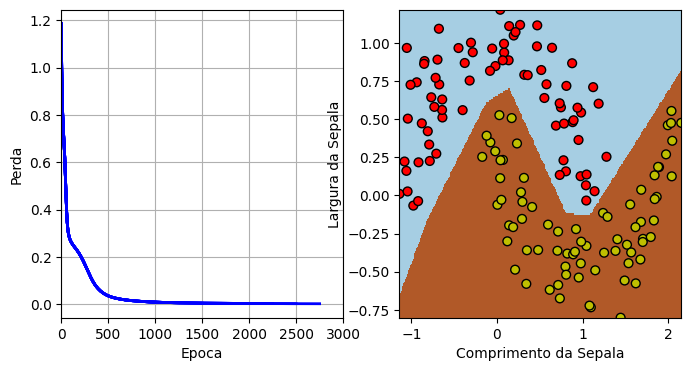

In [26]:
class Modelo(nn.Module):
    def __init__(self):
        super(Modelo, self).__init__()
        self.dense = nn.Sequential(
            nn.Linear(2, 10),
            nn.ReLU(),
            nn.Linear(10, 8),
            nn.ReLU(),
            nn.Linear(8,3),
        )

    def forward(self, x):
        x = self.dense(x)
        return x

model = Modelo()
print("New Model Architecture:")
print(model)

lr = 0.15

optimizer = torch.optim.SGD(model.parameters(), lr=lr)

criterion = nn.CrossEntropyLoss()

batch_size = 150
nb_epoch = 3000

boundary_plot = BoundaryPlotter(model, Xc, Y, nb_epoch)

boundary_plot.on_train_begin()
losses = []
for i in range(nb_epoch):
    # predict da rede
    output = model(Variable(X_tensor))

    loss = criterion(output, Variable(Y_tensor))

    # zero, backpropagation gradient, atualiza param gradiente descendente
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.data)

    boundary_plot.on_epoch_end(i, {'loss': loss.data})

print('\nFinal loss (new model):', loss.data)

Y_hat = predict(model, X_tensor)
accuracy = (Y_hat == Y).mean()
print('\nTraining Accuracy (new model): ', accuracy)

import pandas as pd
print('\nConfusion Matrix (new model):')
print(pd.crosstab(Y_hat, Y))


2) Comparando os dois resultados é possivel ver a ineficiencia da função sigmoid para este caso. Certamente isso se deve ao fato de se tratar de uma amostra tão pequena, os gradientes são espremidos, o que torna o aprendizado lento e estagnado. Fenômeno que também é chamado de Vanishing Gradient.



Final loss (Sigmoid model): tensor(0.2778)

Training Accuracy (Sigmoid model):  0.88

Confusion Matrix (Sigmoid model):
col_0   0   1
row_0        
0      66   9
1       9  66


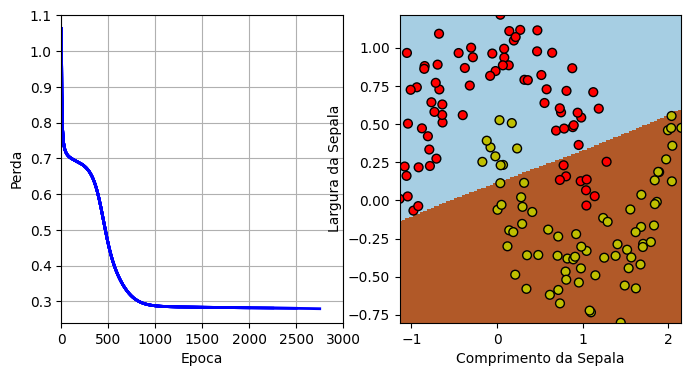

In [27]:
class Modelo(nn.Module):
    def __init__(self):
        super(Modelo, self).__init__()
        self.dense = nn.Sequential(
            nn.Linear(2, 10),
            nn.Sigmoid(),
            nn.Linear(10, 8),
            nn.Sigmoid(),
            nn.Linear(8,3),
        )

    def forward(self, x):
        x = self.dense(x)
        return x

model = Modelo()
print("New Model Architecture (with Sigmoid):")
print(model)

lr = 0.15

optimizer = torch.optim.SGD(model.parameters(), lr=lr)

criterion = nn.CrossEntropyLoss()

batch_size = 150
nb_epoch = 3000

boundary_plot = BoundaryPlotter(model, Xc, Y, nb_epoch)

boundary_plot.on_train_begin()
losses = []
for i in range(nb_epoch):
    # predict da rede
    output = model(Variable(X_tensor))

    loss = criterion(output, Variable(Y_tensor))

    # zero, backpropagation gradient, atualiza param gradiente descendente
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.data)

    boundary_plot.on_epoch_end(i, {'loss': loss.data})

print('\nFinal loss (Sigmoid model):', loss.data)

Y_hat = predict(model, X_tensor)
accuracy = (Y_hat == Y).mean()
print('\nTraining Accuracy (Sigmoid model): ', accuracy)

import pandas as pd
print('\nConfusion Matrix (Sigmoid model):')
print(pd.crosstab(Y_hat, Y))


3.Para problemas que são **linearmente separáveis**, uma rede linear simples pode ser suficiente. No entanto, o dataset utilizado neste notebook é um problema **não-linear**. Para modelar relações não-lineares e aprender padrões complexos, as funções de ativação não-lineares são cruciais, pois elas introduzem a capacidade de curvatura e flexibilidade na fronteira de decisão da rede. Sem elas, a rede se limita a encontrar uma linha (ou hiperplano) para separar as classes, o que pode ser não ideal para este caso. Como exemplificado no teste abaixo.



Final loss (Linear only): tensor(0.2742)

Training Accuracy (Linear Only):  0.88

Confusion Matrix (Linear Only):
col_0   0   1
row_0        
0      66   9
1       9  66


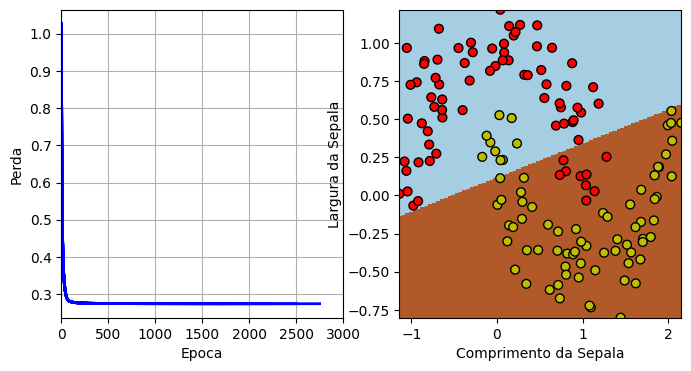

In [28]:
class Modelo(nn.Module):
    def __init__(self):
        super(Modelo, self).__init__()
        self.dense = nn.Sequential(
            nn.Linear(2, 10),
            nn.Linear(10, 8),
            nn.Linear(8,3),          )

    def forward(self, x):
        x = self.dense(x)
        return x

model = Modelo()
print("New Model Architecture (with Sigmoid):")
print(model)

lr = 0.15

optimizer = torch.optim.SGD(model.parameters(), lr=lr)

criterion = nn.CrossEntropyLoss()

batch_size = 150
nb_epoch = 3000

boundary_plot = BoundaryPlotter(model, Xc, Y, nb_epoch)

boundary_plot.on_train_begin()
losses = []
for i in range(nb_epoch):
    # predict da rede
    output = model(Variable(X_tensor))

    loss = criterion(output, Variable(Y_tensor))

    # zero, backpropagation gradient, atualiza param gradiente descendente
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.data)

    boundary_plot.on_epoch_end(i, {'loss': loss.data})

print('\nFinal loss (Linear only):', loss.data)

Y_hat = predict(model, X_tensor)
accuracy = (Y_hat == Y).mean()
print('\nTraining Accuracy (Linear Only): ', accuracy)

import pandas as pd
print('\nConfusion Matrix (Linear Only):')
print(pd.crosstab(Y_hat, Y))
